In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas_datareader.data as web
import datetime

from functions import get_polymarket_event

In [2]:
july_event, july_probs = get_polymarket_event("fed-decision-in-july-181", "2026-07-29")
for name, df in july_probs.items():
    print(name, len(df), "points")

50+ bps decrease 236 points
25 bps decrease 236 points
No change 236 points
25 bps increase 236 points
50+ bps increase 236 points


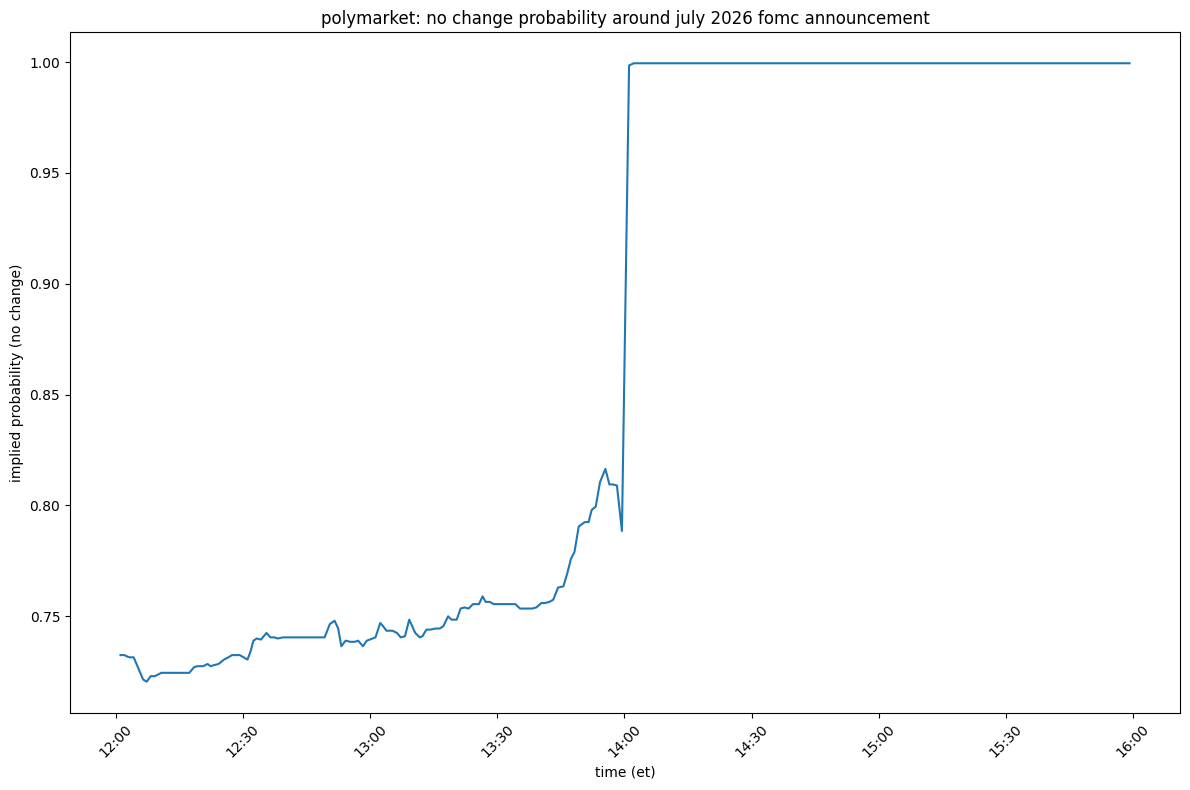

In [3]:
window_df = july_probs['No change'].rename(columns={'t': 'unix_timestamp', 'p': 'implied_probability_no_change'})

fig, ax = plt.subplots(figsize=(12, 8))
ax.plot(window_df['datetime'], window_df['implied_probability_no_change'])
ax.set_title('polymarket: no change probability around july 2026 fomc announcement')
ax.set_xlabel('time (et)')
ax.set_ylabel('implied probability (no change)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M', tz=window_df['datetime'].dt.tz))
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

In [4]:
start = datetime.datetime(2026, 7, 1)
end = datetime.datetime(2026, 7, 28)

effr_full = web.DataReader('EFFR', 'fred', start, end)
r_before = effr_full['EFFR'].mean()
print(r_before)

3.6279999999999992


In [5]:
combined = pd.DataFrame()
for outcome_name, odf in july_probs.items():
    s = odf.set_index('datetime')['p'].resample('1min').last().ffill()
    combined[outcome_name] = s

combined = combined.dropna()
print(combined.head())
print(combined.tail())

                           50+ bps decrease  25 bps decrease  No change  \
datetime                                                                  
2026-07-29 12:01:00-04:00            0.0005           0.0025     0.7325   
2026-07-29 12:02:00-04:00            0.0005           0.0025     0.7320   
2026-07-29 12:03:00-04:00            0.0005           0.0025     0.7315   
2026-07-29 12:04:00-04:00            0.0005           0.0025     0.7315   
2026-07-29 12:05:00-04:00            0.0005           0.0025     0.7260   

                           25 bps increase  50+ bps increase  
datetime                                                      
2026-07-29 12:01:00-04:00           0.2695            0.0035  
2026-07-29 12:02:00-04:00           0.2695            0.0045  
2026-07-29 12:03:00-04:00           0.2695            0.0045  
2026-07-29 12:04:00-04:00           0.2695            0.0045  
2026-07-29 12:05:00-04:00           0.2695            0.0045  
                           50+ bp

In [6]:
prob_sum = (
    combined['50+ bps decrease'] +
    combined['25 bps decrease'] +
    combined['No change'] +
    combined['25 bps increase'] +
    combined['50+ bps increase']
)

combined['r_after'] = (
    (combined['50+ bps decrease'] / prob_sum) * (r_before - 0.50) +
    (combined['25 bps decrease'] / prob_sum) * (r_before - 0.25) +
    (combined['No change'] / prob_sum) * r_before +
    (combined['25 bps increase'] / prob_sum) * (r_before + 0.25) +
    (combined['50+ bps increase'] / prob_sum) * (r_before + 0.50)
)

print(combined[['r_after']].head())
print(combined[['r_after']].tail())

                            r_after
datetime                           
2026-07-29 12:01:00-04:00  3.695675
2026-07-29 12:02:00-04:00  3.696137
2026-07-29 12:03:00-04:00  3.696171
2026-07-29 12:04:00-04:00  3.696171
2026-07-29 12:05:00-04:00  3.696544
                           r_after
datetime                          
2026-07-29 15:55:00-04:00    3.628
2026-07-29 15:56:00-04:00    3.628
2026-07-29 15:57:00-04:00    3.628
2026-07-29 15:58:00-04:00    3.628
2026-07-29 15:59:00-04:00    3.628


In [7]:
zq_df = pd.read_csv('zq_2026.csv')
zq_df['datetime'] = pd.to_datetime(zq_df['time'], unit='s')
zq_df['datetime'] = zq_df['datetime'].dt.tz_localize('UTC').dt.tz_convert('America/New_York')
zq_window = zq_df[(zq_df['datetime'] >= '2026-07-29 12:00:00') & (zq_df['datetime'] <= '2026-07-29 16:00:00')].copy()
zq_window['implied_rate'] = 100 - zq_window['close']
print(zq_window.head())
print(zq_window.tail())

             time    open    high     low   close  Volume  \
18939  1785340800  96.285  96.285  96.285  96.285    1251   
18940  1785340860  96.285  96.285  96.285  96.285      57   
18941  1785340920  96.285  96.285  96.285  96.285     560   
18942  1785340980  96.285  96.285  96.285  96.285     261   
18943  1785341100  96.285  96.285  96.285  96.285      42   

                       datetime  implied_rate  
18939 2026-07-29 12:00:00-04:00         3.715  
18940 2026-07-29 12:01:00-04:00         3.715  
18941 2026-07-29 12:02:00-04:00         3.715  
18942 2026-07-29 12:03:00-04:00         3.715  
18943 2026-07-29 12:05:00-04:00         3.715  
             time    open    high     low   close  Volume  \
19143  1785354840  96.370  96.370  96.370  96.370       8   
19144  1785354900  96.365  96.365  96.365  96.365      31   
19145  1785354960  96.365  96.365  96.365  96.365      15   
19146  1785355080  96.365  96.365  96.365  96.365     243   
19147  1785355140  96.365  96.365  96.36

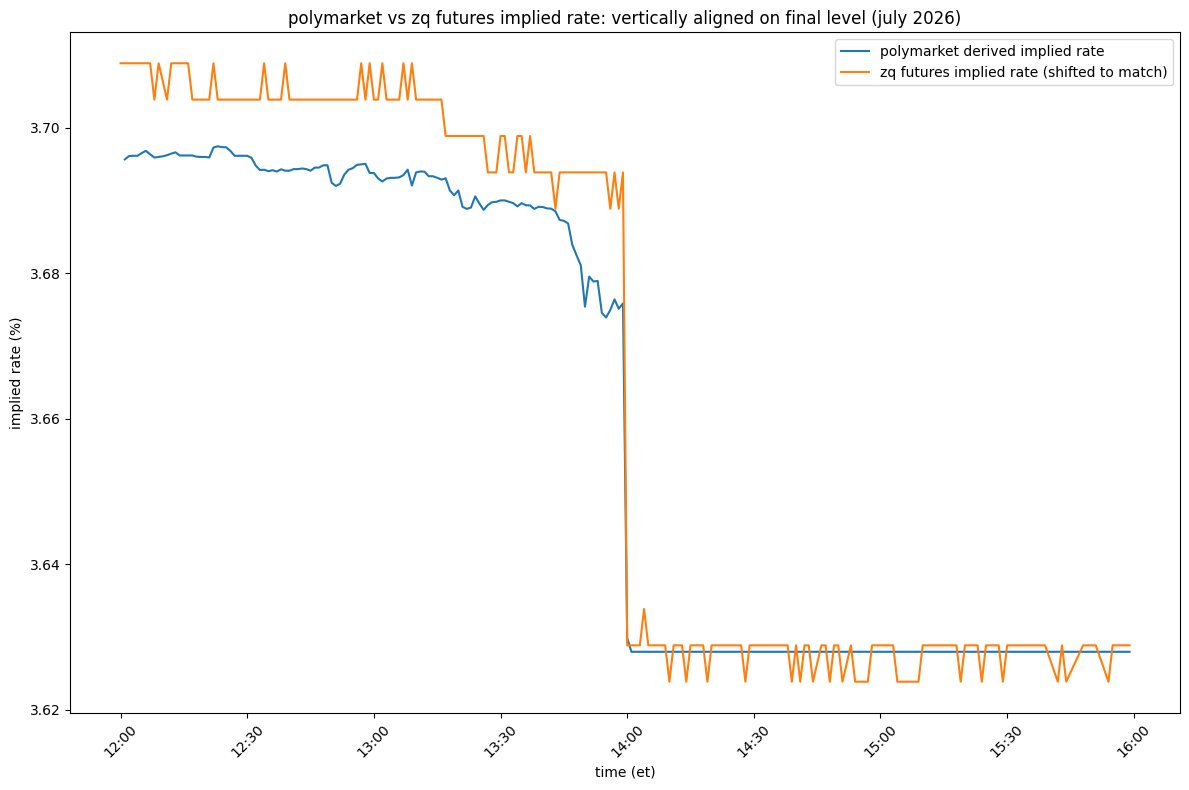

In [8]:
zq_final_level = zq_window[zq_window['datetime'] >= '2026-07-29 15:00:00']['implied_rate'].mean()
poly_final_level = combined[combined.index >= '2026-07-29 15:00:00']['r_after'].mean()
shift_amount = poly_final_level - zq_final_level
zq_window['implied_rate_shifted'] = zq_window['implied_rate'] + shift_amount

fig, ax = plt.subplots(figsize=(12, 8))
ax.plot(combined.index, combined['r_after'], label='polymarket derived implied rate', color='tab:blue')
ax.plot(zq_window['datetime'], zq_window['implied_rate_shifted'], label='zq futures implied rate (shifted to match)', color='tab:orange')
ax.set_title('polymarket vs zq futures implied rate: vertically aligned on final level (july 2026)')
ax.set_xlabel('time (et)')
ax.set_ylabel('implied rate (%)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M', tz=zq_window['datetime'].dt.tz))
ax.tick_params(axis='x', rotation=45)
ax.legend()
plt.tight_layout()
plt.show()

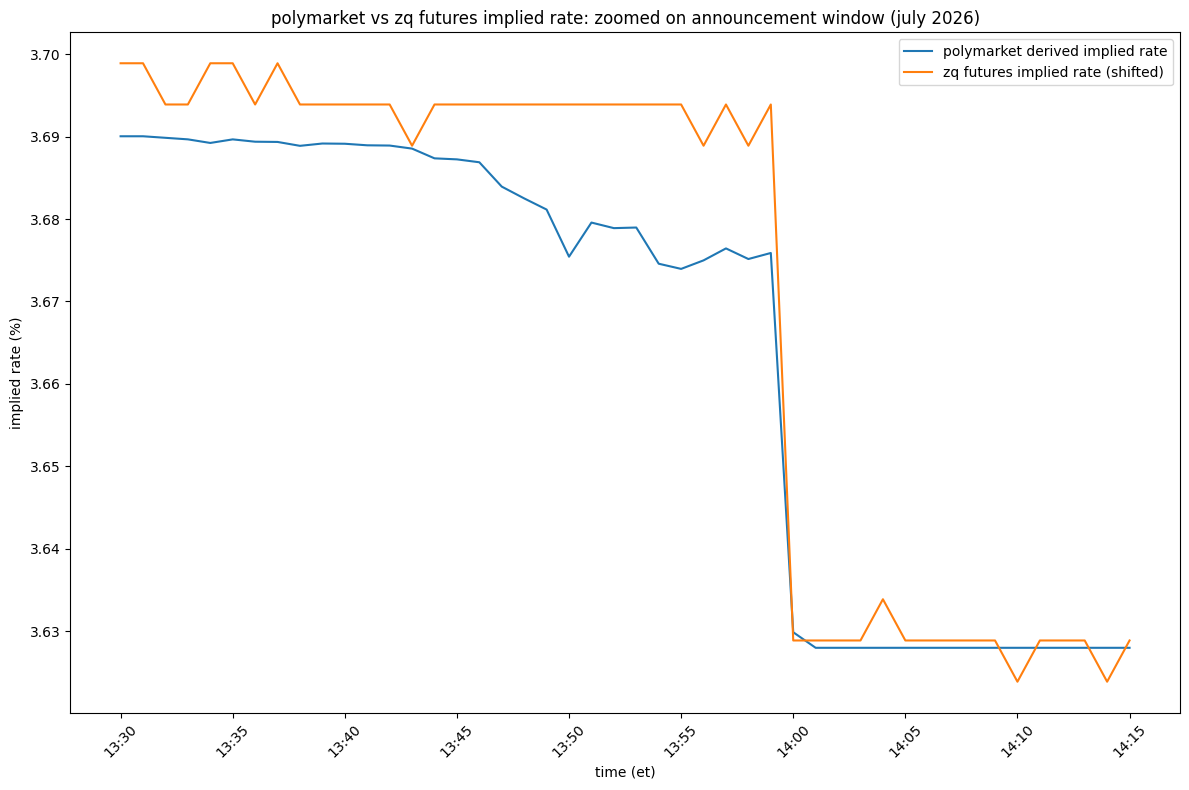

In [9]:
zoom_start = '2026-07-29 13:30:00'
zoom_end = '2026-07-29 14:15:00'

combined_zoom = combined[(combined.index >= zoom_start) & (combined.index <= zoom_end)]
zq_zoom = zq_window[(zq_window['datetime'] >= zoom_start) & (zq_window['datetime'] <= zoom_end)]

fig, ax = plt.subplots(figsize=(12, 8))
ax.plot(combined_zoom.index, combined_zoom['r_after'], label='polymarket derived implied rate', color='tab:blue')
ax.plot(zq_zoom['datetime'], zq_zoom['implied_rate_shifted'], label='zq futures implied rate (shifted)', color='tab:orange')
ax.set_title('polymarket vs zq futures implied rate: zoomed on announcement window (july 2026)')
ax.set_xlabel('time (et)')
ax.set_ylabel('implied rate (%)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M', tz=zq_window['datetime'].dt.tz))
ax.tick_params(axis='x', rotation=45)
ax.legend()
plt.tight_layout()
plt.show()

In [10]:
pre_window = combined[(combined.index >= '2026-07-29 13:40:00') & (combined.index <= '2026-07-29 13:58:00')]
poly_diff_pre = pre_window['r_after'].diff()

zq_pre = zq_window[(zq_window['datetime'] >= '2026-07-29 13:40:00') & (zq_window['datetime'] <= '2026-07-29 13:58:00')]
zq_diff_pre = zq_pre.set_index('datetime')['implied_rate'].diff()

print("polymarket real moves:")
print(poly_diff_pre[poly_diff_pre != 0].dropna())
print("\nzq real moves:")
print(zq_diff_pre[zq_diff_pre != 0].dropna())

polymarket real moves:
datetime
2026-07-29 13:41:00-04:00   -0.000189
2026-07-29 13:42:00-04:00   -0.000030
2026-07-29 13:43:00-04:00   -0.000371
2026-07-29 13:44:00-04:00   -0.001180
2026-07-29 13:45:00-04:00   -0.000124
2026-07-29 13:46:00-04:00   -0.000352
2026-07-29 13:47:00-04:00   -0.002952
2026-07-29 13:48:00-04:00   -0.001429
2026-07-29 13:49:00-04:00   -0.001353
2026-07-29 13:50:00-04:00   -0.005715
2026-07-29 13:51:00-04:00    0.004138
2026-07-29 13:52:00-04:00   -0.000676
2026-07-29 13:53:00-04:00    0.000074
2026-07-29 13:54:00-04:00   -0.004389
2026-07-29 13:55:00-04:00   -0.000627
2026-07-29 13:56:00-04:00    0.001033
2026-07-29 13:57:00-04:00    0.001451
2026-07-29 13:58:00-04:00   -0.001287
Freq: min, Name: r_after, dtype: float64

zq real moves:
datetime
2026-07-29 13:43:00-04:00   -0.005
2026-07-29 13:44:00-04:00    0.005
2026-07-29 13:56:00-04:00   -0.005
2026-07-29 13:57:00-04:00    0.005
2026-07-29 13:58:00-04:00   -0.005
Name: implied_rate, dtype: float64
